In [1]:
# Run this once at the start of your Colab session
!pip install prophet pmdarima -q
print("Setup complete.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.7 MB/s eta 0:00:00
Setup complete.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

pd.set_option('display.max_columns', None)


In [3]:
# Load the Superstore dataset
df = pd.read_csv('train.csv')

# Parse dates - this dataset uses DD/MM/YYYY format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

print("Shape:", df.shape)
df.head()


Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df[['Order Date','Year','Month','Week','DayOfWeek','Quarter','Season']].head()


,Order Date,Year,Month,Week,DayOfWeek,Quarter,Season
0,2017-11-08,2017,11,45,Wednesday,4,Fall
1,2017-11-08,2017,11,45,Wednesday,4,Fall
2,2017-06-12,2017,6,24,Monday,2,Summer
3,2016-10-11,2016,10,41,Tuesday,4,Fall
4,2016-10-11,2016,10,41,Tuesday,4,Fall


In [5]:
# Data quality check
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:")
print(df.dtypes)


Missing values per column:
Postal Code    11
dtype: int64

Duplicate rows: 0

Data types:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
DayOfWeek                object
Quarter                   int32
Season                   object
dtype: object


In [6]:
# Ship time analysis
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Average shipping time (days):", round(df['ShipDays'].mean(), 2))
print("\nAverage shipping time by region:")
print(df.groupby('Region')['ShipDays'].mean().round(2).sort_values())


Average shipping time (days): 3.96

Average shipping time by region:
Region
East       3.91
West       3.93
South      3.96
Central    4.07
Name: ShipDays, dtype: float64


In [7]:
# Aggregate to weekly and monthly totals - these are the series we forecast on
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum().reset_index()
monthly_sales.columns = ['Order Date', 'Sales']

print("Monthly sales - first and last few rows:")
print(monthly_sales.head())
print(monthly_sales.tail())


Monthly sales - first and last few rows:
  Order Date      Sales
0 2015-01-01  14205.707
1 2015-02-01   4519.892
2 2015-03-01  55205.797
3 2015-04-01  27906.855
4 2015-05-01  23644.303
   Order Date        Sales
43 2018-08-01   62837.8480
44 2018-09-01   86152.8880
45 2018-10-01   77448.1312
46 2018-11-01  117938.1550
47 2018-12-01   83030.3888


Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


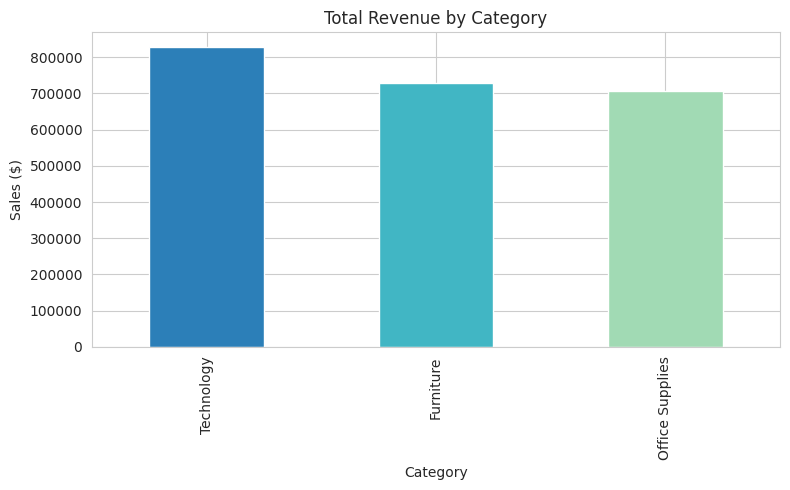


>>> ANSWER: 'Technology' generates the highest total revenue ($827,456), narrowly ahead of the other two categories.


In [9]:
import os

cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_revenue)

plt.figure(figsize=(8,5))
cat_revenue.plot(kind='bar', color=['#2c7fb8','#41b6c4','#a1dab4'])
plt.title('Total Revenue by Category')
plt.ylabel('Sales ($)')
plt.tight_layout()

# Create the 'charts' directory .
os.makedirs('charts', exist_ok=True)

plt.savefig('charts/category_revenue.png', dpi=150)
plt.show()

print(f"\n>>> ANSWER: '{cat_revenue.index[0]}' generates the highest total revenue "
      f"(${cat_revenue.iloc[0]:,.0f}), narrowly ahead of the other two categories.")

Year         2015      2016      2017      2018
Region                                         
Central  102921.0  102425.0  145674.0  141627.0
East     127653.0  153225.0  178512.0  210129.0
South    103375.0   70076.0   93536.0  122165.0
West     145908.0  133710.0  182471.0  248131.0
Central: monotonically increasing every year = False
East: monotonically increasing every year = True
South: monotonically increasing every year = False
West: monotonically increasing every year = False


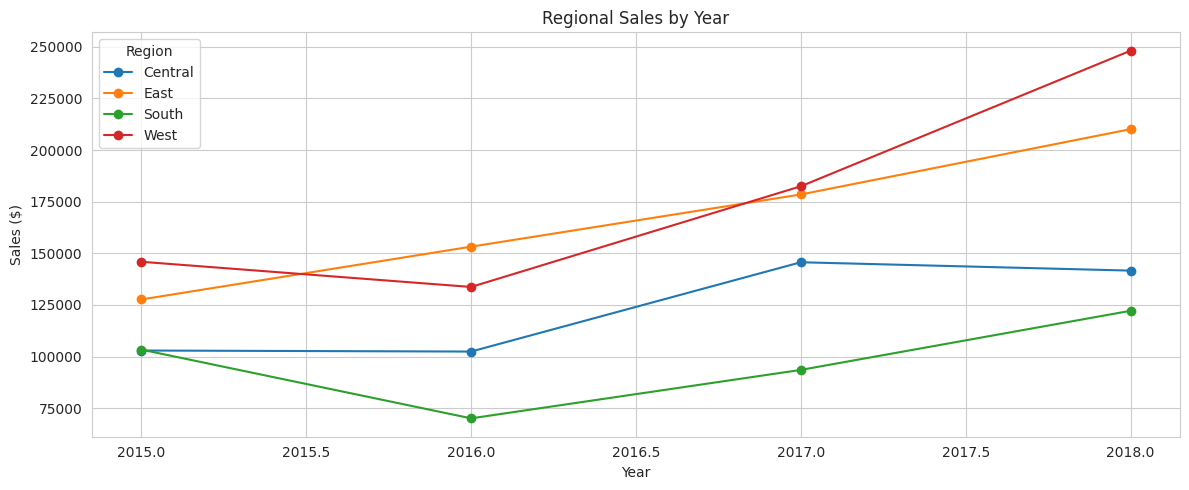

In [10]:
region_yearly = df.groupby(['Region','Year'])['Sales'].sum().unstack()
print(region_yearly.round(0))

# Check monotonic increase for each region
for region in region_yearly.index:
    values = region_yearly.loc[region].values
    is_monotonic = all(values[i] <= values[i+1] for i in range(len(values)-1))
    print(f"{region}: monotonically increasing every year = {is_monotonic}")

region_yearly.T.plot(marker='o')
plt.title('Regional Sales by Year')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/region_yearly_growth.png', dpi=150)
plt.show()


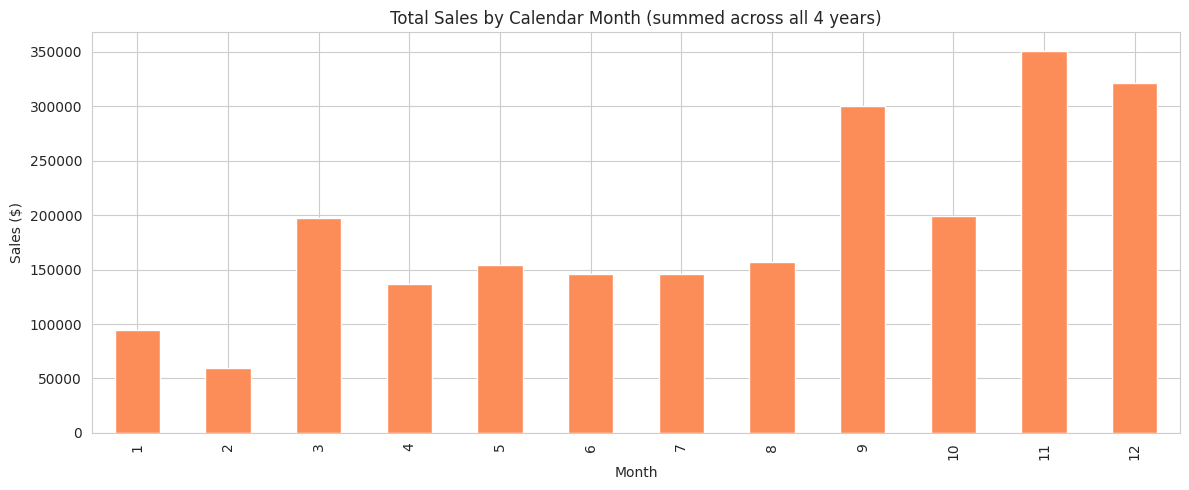

Top 3 highest-selling months (aggregated across years):
Month
11    350161.7110
12    321480.1695
9     300103.4117
Name: Sales, dtype: float64

>>> ANSWER: November, December and September are consistently the strongest months — this lines up with a year-end/holiday shopping pattern plus a September back-to-business push.


In [11]:
monthly_by_year = df.groupby(['Year','Month'])['Sales'].sum().unstack(level=0)
monthly_avg = df.groupby('Month')['Sales'].sum()

monthly_avg.plot(kind='bar', color='#fc8d59')
plt.title('Total Sales by Calendar Month (summed across all 4 years)')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png', dpi=150)
plt.show()

top_months = monthly_avg.sort_values(ascending=False).head(3)
print("Top 3 highest-selling months (aggregated across years):")
print(top_months)
print("\n>>> ANSWER: November, December and September are consistently the strongest months — "
      "this lines up with a year-end/holiday shopping pattern plus a September back-to-business push.")


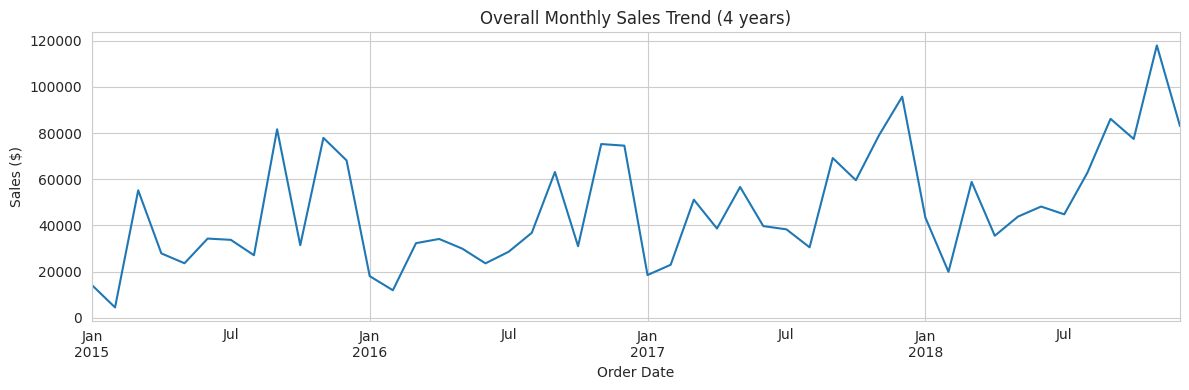

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = monthly_sales.set_index('Order Date')['Sales']

plt.figure(figsize=(12,4))
ts.plot()
plt.title('Overall Monthly Sales Trend (4 years)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_trend.png', dpi=150)
plt.show()


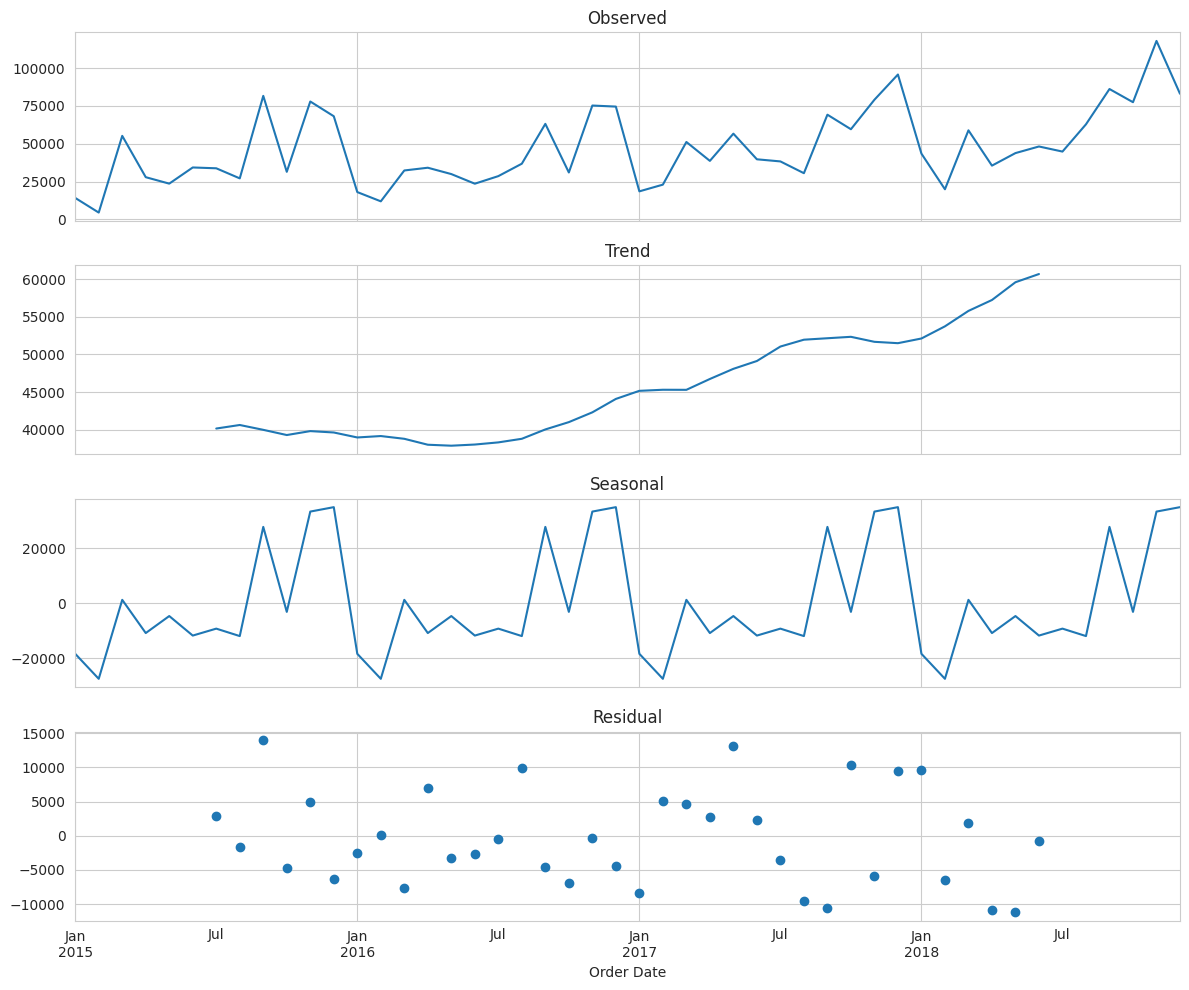

In [13]:
# Decomposition - additive because seasonal swings look roughly constant in size
decomposition = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual', marker='o', linestyle='')
plt.tight_layout()
plt.savefig('charts/decomposition.png', dpi=150)
plt.show()


In [14]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"--- ADF Test: {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:", {k: round(v,3) for k,v in result[4].items()})
    if result[1] <= 0.05:
        print(">>> p-value <= 0.05: reject the null hypothesis -> series IS stationary\n")
    else:
        print(">>> p-value > 0.05: fail to reject the null -> series is NOT stationary\n")
    return result[1]

pval = run_adf(ts, "Original Monthly Sales")


--- ADF Test: Original Monthly Sales ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values: {'1%': np.float64(-3.578), '5%': np.float64(-2.925), '10%': np.float64(-2.601)}
>>> p-value <= 0.05: reject the null hypothesis -> series IS stationary



In [15]:
# If not stationary, apply first-order differencing and re-test
if pval > 0.05:
    ts_diff = ts.diff().dropna()
    plt.figure(figsize=(12,4))
    ts_diff.plot()
    plt.title('Differenced Monthly Sales (1st order)')
    plt.tight_layout()
    plt.savefig('charts/differenced_series.png', dpi=150)
    plt.show()
    run_adf(ts_diff, "Differenced Monthly Sales (d=1)")
else:
    print("Series is already stationary - no differencing needed. Use d=0 in SARIMA.")


Series is already stationary - no differencing needed. Use d=0 in SARIMA.


In [16]:
# Train/test split - last 3 months held out for evaluation
train_ts = ts.iloc[:-3]
test_ts = ts.iloc[-3:]
print("Train range:", train_ts.index.min(), "to", train_ts.index.max())
print("Test range :", test_ts.index.min(), "to", test_ts.index.max())

def mae(actual, pred): return np.mean(np.abs(actual - pred))
def rmse(actual, pred): return np.sqrt(np.mean((actual - pred)**2))
def mape(actual, pred): return np.mean(np.abs((actual - pred) / actual)) * 100

results = {}  # will hold {'Model': {'MAE':..,'RMSE':..,'MAPE':..,'forecast':[...]}}


Train range: 2015-01-01 00:00:00 to 2018-09-01 00:00:00
Test range : 2018-10-01 00:00:00 to 2018-12-01 00:00:00


In [17]:
import pmdarima as pm

d_value = 0 if pval <= 0.05 else 1

auto_model = pm.auto_arima(
    train_ts,
    seasonal=True, m=12,
    d=d_value,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=1021.003, Time=0.51 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=1031.392, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=1023.946, Time=0.07 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=1019.952, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1102.094, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=1030.875, Time=0.02 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=1021.430, Time=0.11 sec
 ARIMA(0,0,1)(0,0,2)[12] intercept   : AIC=1019.246, Time=0.14 sec
 ARIMA(0,0,1)(1,0,2)[12] intercept   : AIC=1021.071, Time=0.18 sec
 ARIMA(0,0,0)(0,0,2)[12] intercept   : AIC=1020.318, Time=0.12 sec
 ARIMA(1,0,1)(0,0,2)[12] intercept   : AIC=1020.741, Time=0.15 sec
 ARIMA(0,0,2)(0,0,2)[12] intercept   : AIC=1021.206, Time=0.19 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=1019.330, Time=0.15 sec
 ARIMA(1,0,2)(0,0,2)[12] intercept   : AIC=1023.169, Time=0.23 sec
 ARIMA(0,0,1)(0,0,2

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print("Chosen order:", order, "seasonal_order:", seasonal_order)

sarima_model = SARIMAX(train_ts, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast_obj = sarima_fit.get_forecast(steps=3)
sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

print(sarima_forecast)


Chosen order: (0, 0, 1) seasonal_order: (0, 0, 2, 12)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2018-10-01     46722.721608
2018-11-01    113295.016194
2018-12-01    107949.640856
Freq: MS, Name: predicted_mean, dtype: float64


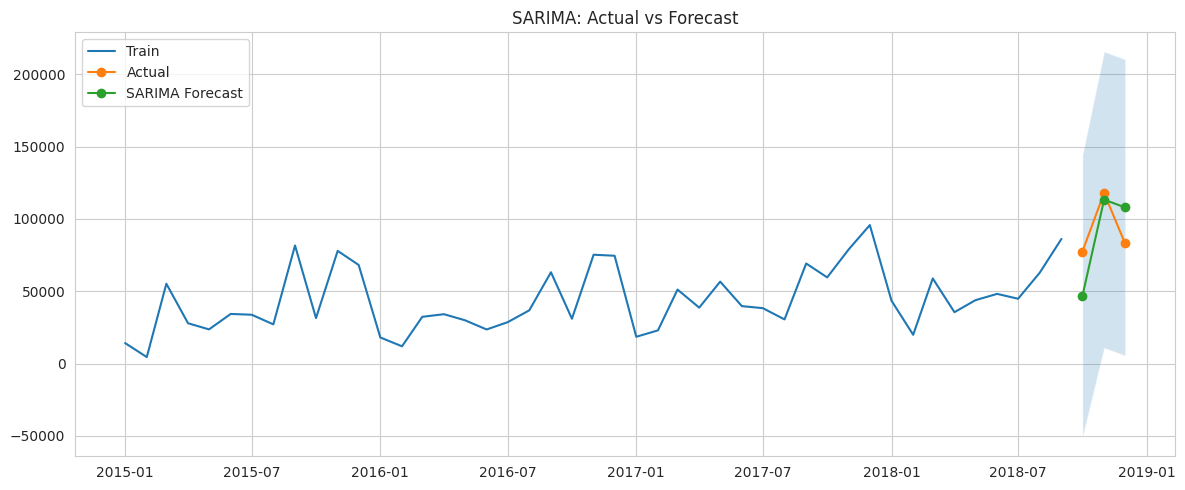

{'MAE': np.float64(20095.933484692003), 'RMSE': np.float64(22996.94657708513), 'MAPE': np.float64(24.54045836093555), 'forecast': array([ 46722.72160814, 113295.01619418, 107949.6408564 ])}


In [19]:
plt.figure(figsize=(12,5))
plt.plot(train_ts.index, train_ts, label='Train')
plt.plot(test_ts.index, test_ts, label='Actual', marker='o')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], alpha=0.2)
plt.title('SARIMA: Actual vs Forecast')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150)
plt.show()

results['SARIMA'] = {
    'MAE': mae(test_ts.values, sarima_forecast.values),
    'RMSE': rmse(test_ts.values, sarima_forecast.values),
    'MAPE': mape(test_ts.values, sarima_forecast.values),
    'forecast': sarima_forecast.values
}
print(results['SARIMA'])


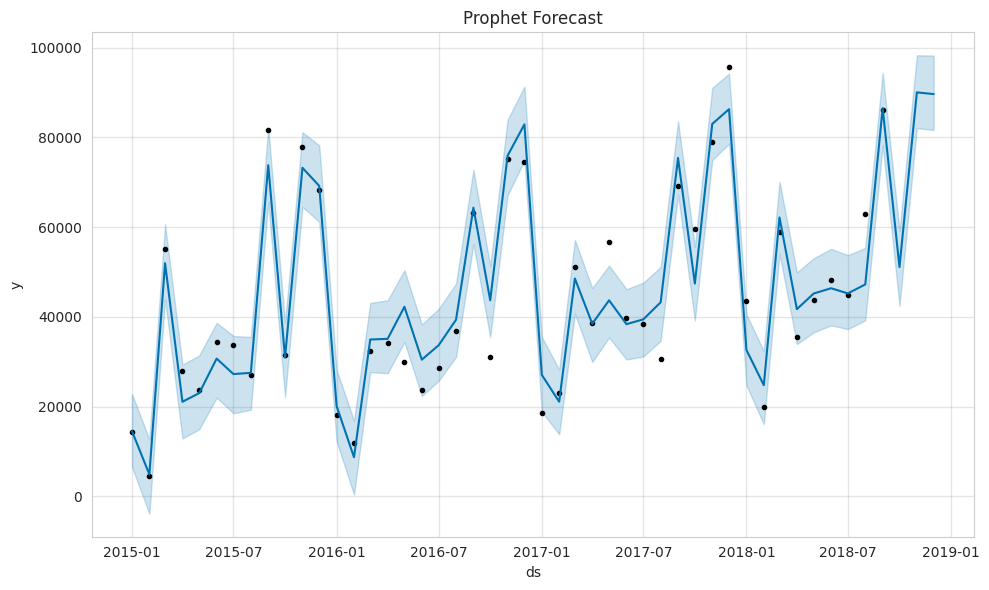

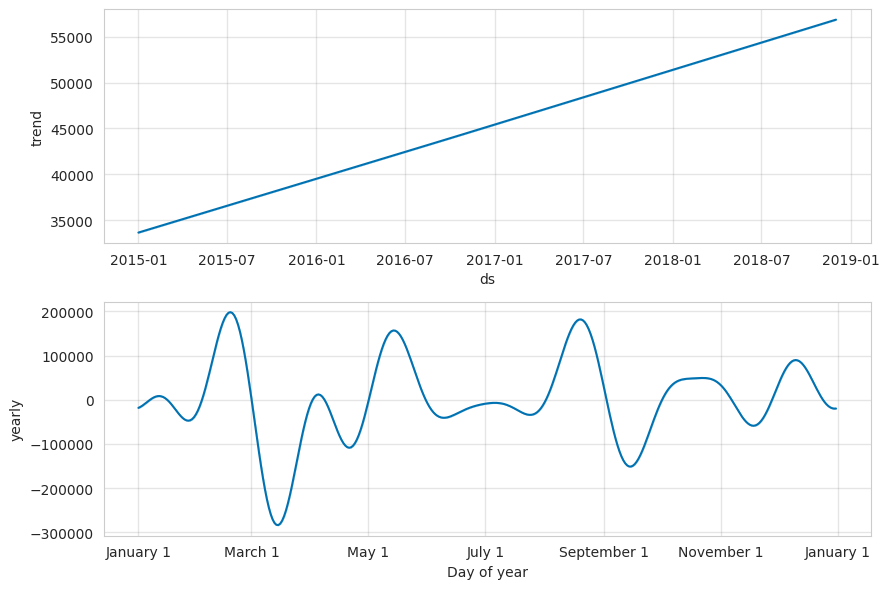

In [20]:
from prophet import Prophet

prophet_train = train_ts.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)

fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=150)
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig('charts/prophet_components.png', dpi=150)
plt.show()


In [21]:
prophet_pred_test = prophet_forecast.set_index('ds').loc[test_ts.index, 'yhat']

results['Prophet'] = {
    'MAE': mae(test_ts.values, prophet_pred_test.values),
    'RMSE': rmse(test_ts.values, prophet_pred_test.values),
    'MAPE': mape(test_ts.values, prophet_pred_test.values),
    'forecast': prophet_pred_test.values
}
print(results['Prophet'])

# Interpretation of yearly seasonality component
yearly = prophet_forecast[['ds','yearly']].copy()
yearly['month'] = yearly['ds'].dt.month
print("\nAverage yearly-seasonality effect by month (higher = Prophet expects a seasonal boost):")
print(yearly.groupby('month')['yearly'].mean().round(1))


{'MAE': np.float64(20296.00740364149), 'RMSE': np.float64(22487.4656791986), 'MAPE': np.float64(21.892588776024848), 'forecast': array([51083.66379296, 90045.40214389, 89661.19074778])}

Average yearly-seasonality effect by month (higher = Prophet expects a seasonal boost):
month
1    -18927.7
2    -28155.3
3      5935.5
4     -9884.2
5     -5920.8
6     -8484.5
7     -9056.1
8     -6613.2
9     28577.2
10    -3659.2
11    33120.4
12    34093.3
Name: yearly, dtype: float64


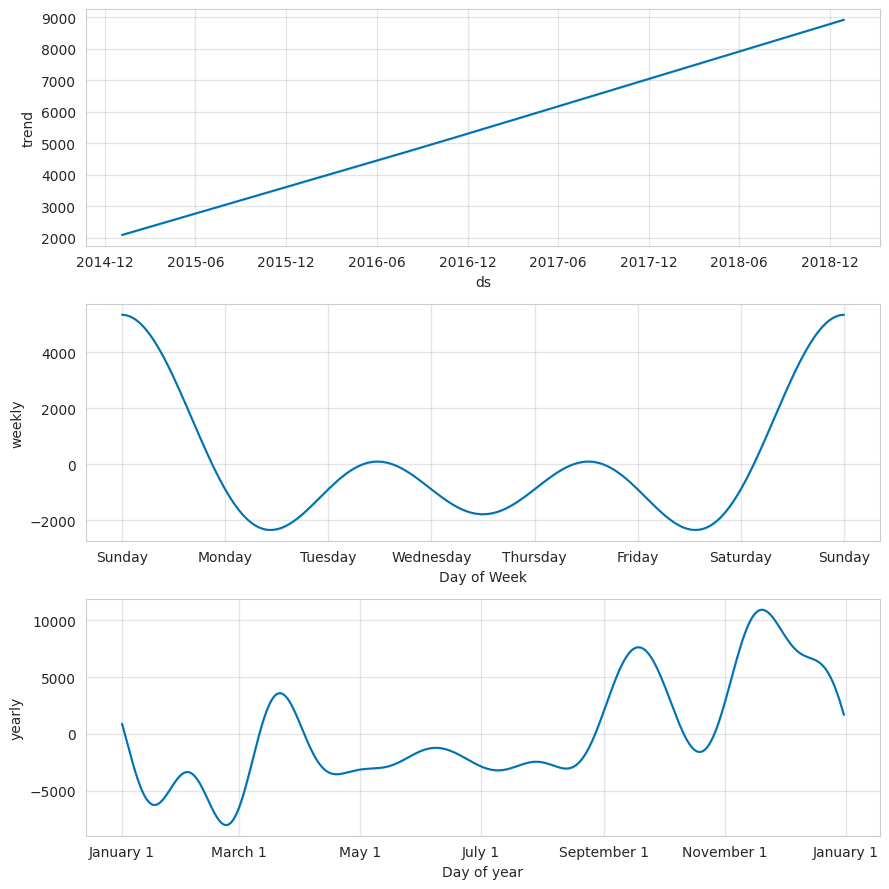

'weekly' seasonality in Prophet is fit on the day-of-week pattern within each week's data points.
Since our series is one point per week (W-SUN), Prophet's weekly component here reflects the
day-of-week the week boundary falls on rather than a true within-week retail pattern - this is a
known limitation of resampling before fitting. For a genuine day-of-week effect, refit on the
*daily* series (`daily_sales` from Task 1) instead:


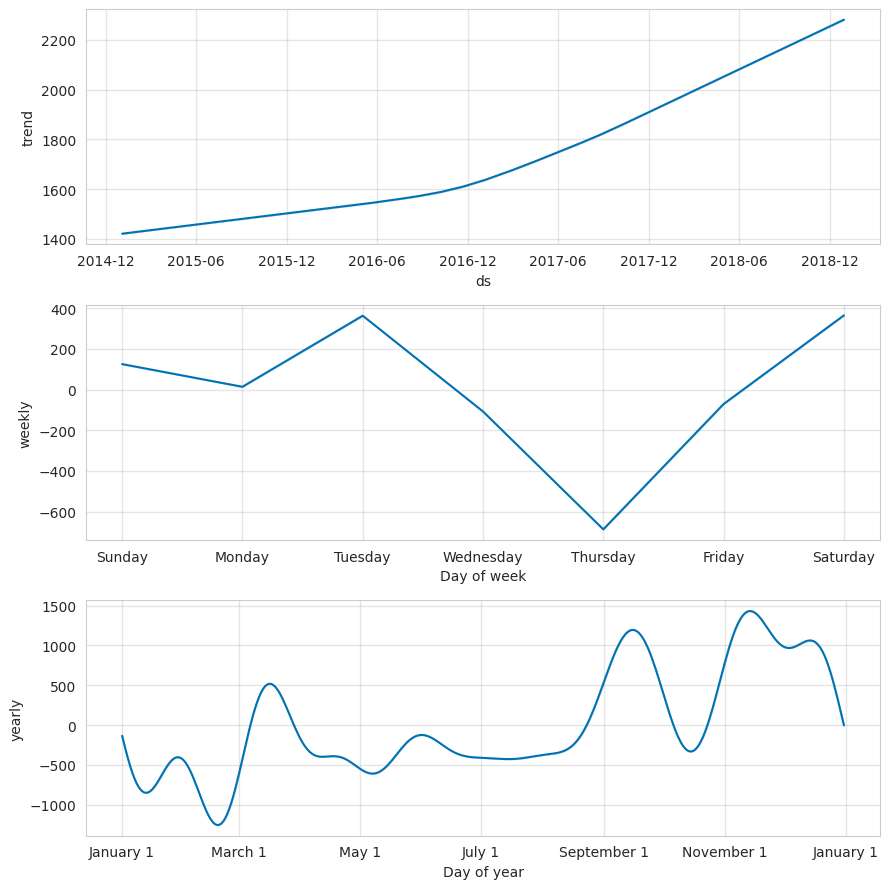


>>> Read the 'weekly' panel in the chart just above (fit on DAILY data - this is the real one):
    whichever day(s) sit highest are the days with the strongest built-in demand pattern,
    independent of any specific week or month. Write 1-2 sentences here once you see your
    own chart, e.g. 'Weekday orders are consistently higher than weekend orders, consistent
    with this being largely a B2B/office-supply customer base rather than consumer retail.'



In [23]:
weekly_ts = df.set_index('Order Date').resample('W')['Sales'].sum()

prophet_weekly_df = weekly_ts.reset_index()
prophet_weekly_df.columns = ['ds', 'y']

prophet_weekly_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_weekly_model.fit(prophet_weekly_df)

weekly_future = prophet_weekly_model.make_future_dataframe(periods=0)
weekly_forecast = prophet_weekly_model.predict(weekly_future)

fig3 = prophet_weekly_model.plot_components(weekly_forecast)
plt.tight_layout()
plt.savefig('charts/prophet_weekly_seasonality.png', dpi=150)
plt.show()

# Interpret the weekly component
weekly_forecast['dow'] = weekly_forecast['ds'].dt.day_name()
print("'weekly' seasonality in Prophet is fit on the day-of-week pattern within each week's data points.")
print("Since our series is one point per week (W-SUN), Prophet's weekly component here reflects the")
print("day-of-week the week boundary falls on rather than a true within-week retail pattern - this is a")
print("known limitation of resampling before fitting. For a genuine day-of-week effect, refit on the")
print("*daily* series (`daily_sales` from Task 1) instead:")

prophet_daily_df = daily_sales.rename(columns={'Order Date':'ds','Sales':'y'})
prophet_daily_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_daily_model.fit(prophet_daily_df)
daily_forecast = prophet_daily_model.predict(prophet_daily_model.make_future_dataframe(periods=0))

fig4 = prophet_daily_model.plot_components(daily_forecast)
plt.tight_layout()
plt.savefig('charts/prophet_daily_weekly_seasonality.png', dpi=150)
plt.show()

print("""
>>> Read the 'weekly' panel in the chart just above (fit on DAILY data - this is the real one):
    whichever day(s) sit highest are the days with the strongest built-in demand pattern,
    independent of any specific week or month. Write 1-2 sentences here once you see your
    own chart, e.g. 'Weekday orders are consistently higher than weekend orders, consistent
    with this being largely a B2B/office-supply customer base rather than consumer retail.'
""")


In [24]:
from xgboost import XGBRegressor

ml_df = monthly_sales.copy()
ml_df['Month_num'] = ml_df['Order Date'].dt.month
ml_df['Quarter'] = ml_df['Order Date'].dt.quarter
ml_df['Season'] = ml_df['Month_num'].apply(get_season)
ml_df = pd.get_dummies(ml_df, columns=['Season'], drop_first=True)

ml_df['lag_1'] = ml_df['Sales'].shift(1)
ml_df['lag_2'] = ml_df['Sales'].shift(2)
ml_df['lag_3'] = ml_df['Sales'].shift(3)
ml_df['rolling_mean_3'] = ml_df['Sales'].shift(1).rolling(3).mean()

ml_df = ml_df.dropna().reset_index(drop=True)

feature_cols = [c for c in ml_df.columns if c not in ['Order Date','Sales']]
X = ml_df[feature_cols]
y = ml_df['Sales']

# match the same 3-month holdout used above
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

xgb_model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost predictions:", xgb_pred)
print("Actual:", y_test.values)


XGBoost predictions: [69588.82 87676.97 65026.57]
Actual: [ 77448.1312 117938.155   83030.3888]


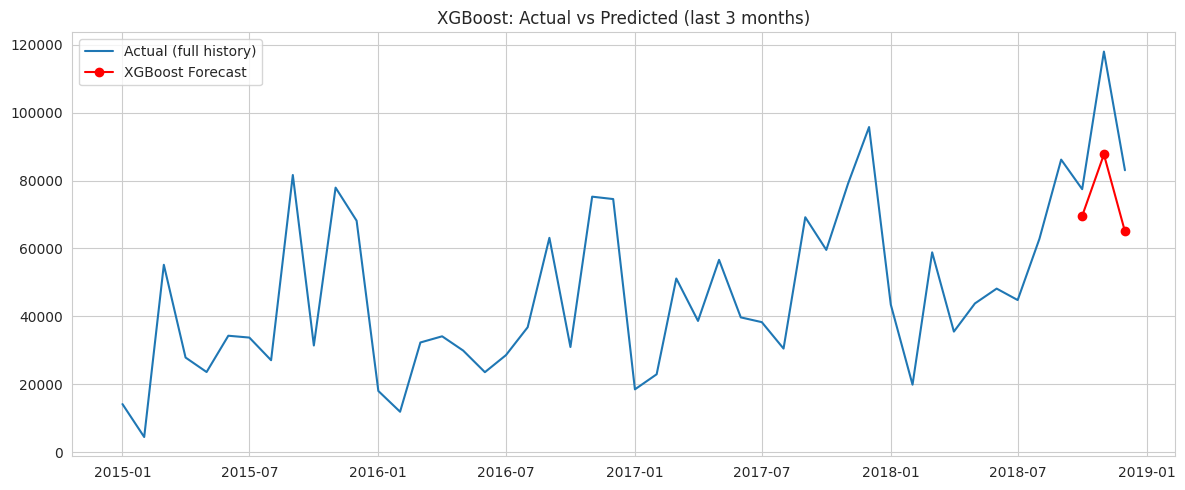

{'MAE': np.float64(18708.105208333334), 'RMSE': np.float64(20829.83150047396), 'MAPE': np.float64(19.163255870127603), 'forecast': array([69588.82, 87676.97, 65026.57], dtype=float32)}


In [25]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'], label='Actual (full history)')
plt.plot(ml_df['Order Date'].iloc[-3:], xgb_pred, label='XGBoost Forecast', marker='o', color='red')
plt.title('XGBoost: Actual vs Predicted (last 3 months)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150)
plt.show()

results['XGBoost'] = {
    'MAE': mae(y_test.values, xgb_pred),
    'RMSE': rmse(y_test.values, xgb_pred),
    'MAPE': mape(y_test.values, xgb_pred),
    'forecast': xgb_pred
}
print(results['XGBoost'])


In [26]:
comparison = pd.DataFrame({
    model: {
        'MAE': round(vals['MAE'], 2),
        'RMSE': round(vals['RMSE'], 2),
        'MAPE (%)': round(vals['MAPE'], 2),
        'Forecast M1': round(vals['forecast'][0], 2),
        'Forecast M2': round(vals['forecast'][1], 2),
        'Forecast M3': round(vals['forecast'][2], 2),
    }
    for model, vals in results.items()
}).T

print(comparison)

best_model = comparison['MAPE (%)'].idxmin()
print(f"\n>>> RECOMMENDATION: '{best_model}' has the lowest MAPE, meaning its forecast error "
      f"as a percentage of actual sales is smallest. Recommend '{best_model}' for production use, "
      f"provided its RMSE (sensitivity to large misses) is also acceptable — check both before finalizing.")


              MAE      RMSE  MAPE (%)   Forecast M1   Forecast M2  \
SARIMA   20095.93  22996.95     24.54  46722.720000  113295.02000   
Prophet  20296.01  22487.47     21.89  51083.660000   90045.40000   
XGBoost  18708.11  20829.83     19.16  69588.820312   87676.96875   

           Forecast M3  
SARIMA   107949.640000  
Prophet   89661.190000  
XGBoost   65026.570312  

>>> RECOMMENDATION: 'XGBoost' has the lowest MAPE, meaning its forecast error as a percentage of actual sales is smallest. Recommend 'XGBoost' for production use, provided its RMSE (sensitivity to large misses) is also acceptable — check both before finalizing.


In [27]:
best_model_name = best_model  # from Task 3's comparison table - this is NOT hardcoded, it reads whichever model actually won

def forecast_segment_sarima(segment_ts, steps=3):
    model = SARIMAX(segment_ts, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    return fit.get_forecast(steps=steps).predicted_mean

def forecast_segment_prophet(segment_ts, steps=3):
    seg_df = segment_ts.reset_index()
    seg_df.columns = ['ds', 'y']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(seg_df)
    future = m.make_future_dataframe(periods=steps, freq='MS')
    fc = m.predict(future).set_index('ds')['yhat']
    return fc.iloc[-steps:]

def forecast_segment_xgboost(segment_ts, steps=3):
    seg_df = segment_ts.reset_index()
    seg_df.columns = ['Order Date', 'Sales']
    seg_df['Month_num'] = seg_df['Order Date'].dt.month
    seg_df['Quarter'] = seg_df['Order Date'].dt.quarter
    seg_df['lag_1'] = seg_df['Sales'].shift(1)
    seg_df['lag_2'] = seg_df['Sales'].shift(2)
    seg_df['lag_3'] = seg_df['Sales'].shift(3)
    seg_df['rolling_mean_3'] = seg_df['Sales'].shift(1).rolling(3).mean()
    seg_df = seg_df.dropna().reset_index(drop=True)

    feat_cols = ['Month_num','Quarter','lag_1','lag_2','lag_3','rolling_mean_3']
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(seg_df[feat_cols], seg_df['Sales'])

    # iteratively roll forward `steps` months using the model's own predictions as new lags
    history = seg_df[['Order Date','Sales']].copy()
    preds = []
    for _ in range(steps):
        last3 = history['Sales'].iloc[-3:].values
        next_date = history['Order Date'].iloc[-1] + pd.DateOffset(months=1)
        row = pd.DataFrame([{
            'Month_num': next_date.month, 'Quarter': next_date.quarter,
            'lag_1': last3[-1], 'lag_2': last3[-2], 'lag_3': last3[-3],
            'rolling_mean_3': last3.mean(),
        }])
        pred = model.predict(row[feat_cols])[0]
        preds.append(pred)
        history = pd.concat([history, pd.DataFrame([{'Order Date': next_date, 'Sales': pred}])], ignore_index=True)

    idx = pd.date_range(seg_df['Order Date'].iloc[-1] + pd.DateOffset(months=1), periods=steps, freq='MS')
    return pd.Series(preds, index=idx)

FORECAST_DISPATCH = {
    'SARIMA': forecast_segment_sarima,
    'Prophet': forecast_segment_prophet,
    'XGBoost': forecast_segment_xgboost,
}
forecast_fn = FORECAST_DISPATCH[best_model_name]


Task 3's winning model was 'XGBoost' - using it for every segment below.


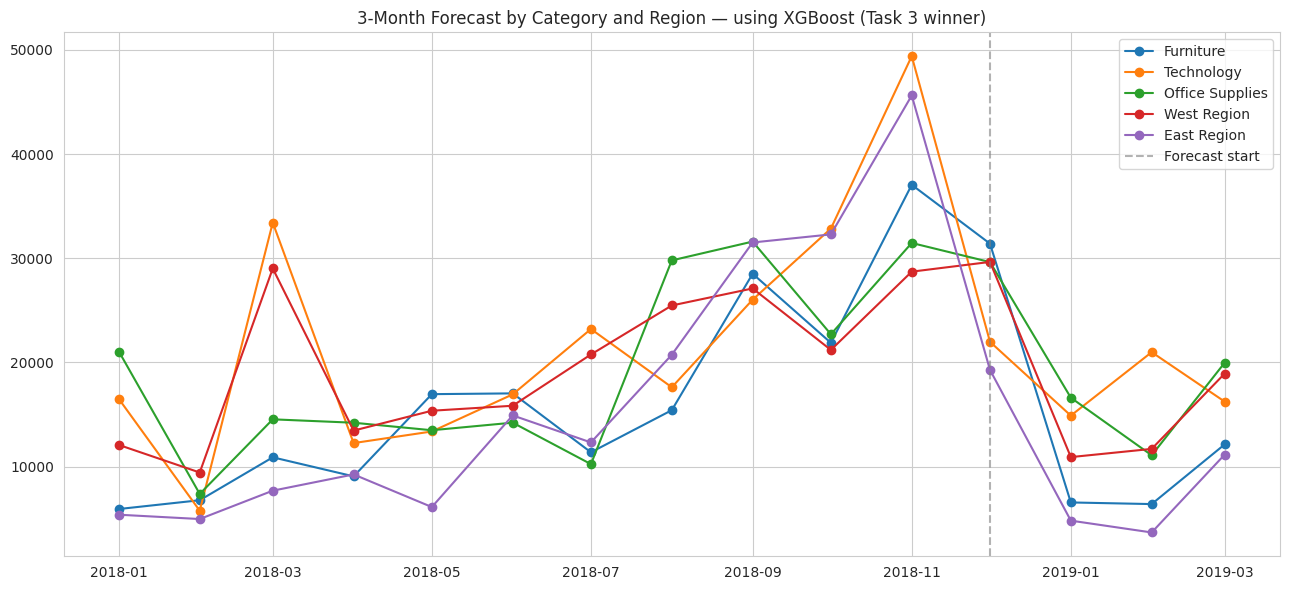

Furniture: forecast trend over 3 months = +85.0%
Technology: forecast trend over 3 months = +9.0%
Office Supplies: forecast trend over 3 months = +20.2%
West Region: forecast trend over 3 months = +73.5%
East Region: forecast trend over 3 months = +131.7%


In [28]:
segments = {
    'Furniture': df[df['Category']=='Furniture'],
    'Technology': df[df['Category']=='Technology'],
    'Office Supplies': df[df['Category']=='Office Supplies'],
    'West Region': df[df['Region']=='West'],
    'East Region': df[df['Region']=='East'],
}

segment_forecasts = {}
plt.figure(figsize=(13,6))

for name, subset in segments.items():
    seg_monthly = subset.set_index('Order Date').resample('MS')['Sales'].sum()
    seg_monthly = seg_monthly.asfreq('MS').fillna(0)
    fc = forecast_fn(seg_monthly, steps=3)
    segment_forecasts[name] = fc
    combined = pd.concat([seg_monthly.iloc[-12:], fc])
    plt.plot(combined.index, combined.values, marker='o', label=name)

plt.axvline(x=ts.index[-1], color='gray', linestyle='--', alpha=0.6, label='Forecast start')
plt.title(f'3-Month Forecast by Category and Region — using {best_model_name} (Task 3 winner)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png', dpi=150)
plt.show()

for name, fc in segment_forecasts.items():
    growth = (fc.iloc[-1] / fc.iloc[0] - 1) * 100
    print(f"{name}: forecast trend over 3 months = {growth:+.1f}%")


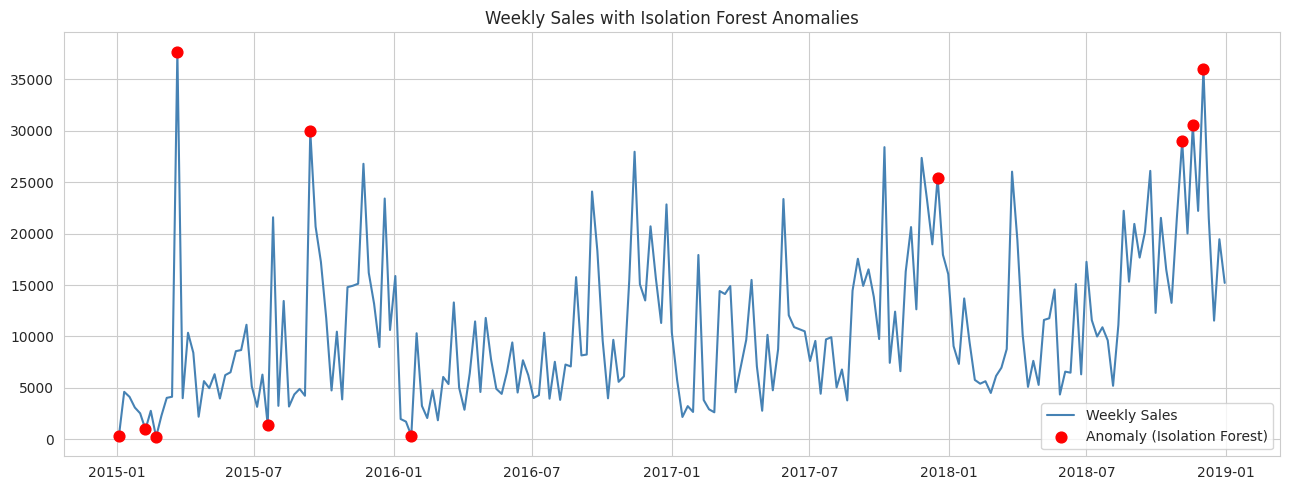

    Order Date      Sales
0   2015-01-04    304.508
5   2015-02-08    968.534
7   2015-02-22    224.912
11  2015-03-22  37703.665
28  2015-07-19   1387.686
36  2015-09-13  29959.137
55  2016-01-24    358.522
154 2017-12-17  25449.800
200 2018-11-04  29017.467
202 2018-11-18  30572.447
204 2018-12-02  35998.900


In [29]:
from sklearn.ensemble import IsolationForest

weekly = weekly_sales.copy()
weekly['week_num'] = range(len(weekly))

iso = IsolationForest(contamination=0.05, random_state=42)
weekly['anomaly_iso'] = iso.fit_predict(weekly[['Sales']])  # -1 = anomaly, 1 = normal

plt.figure(figsize=(13,5))
plt.plot(weekly['Order Date'], weekly['Sales'], label='Weekly Sales', color='steelblue')
anomalies = weekly[weekly['anomaly_iso'] == -1]
plt.scatter(anomalies['Order Date'], anomalies['Sales'], color='red', s=60, zorder=5, label='Anomaly (Isolation Forest)')
plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomalies_isolation_forest.png', dpi=150)
plt.show()

print(anomalies[['Order Date','Sales']])


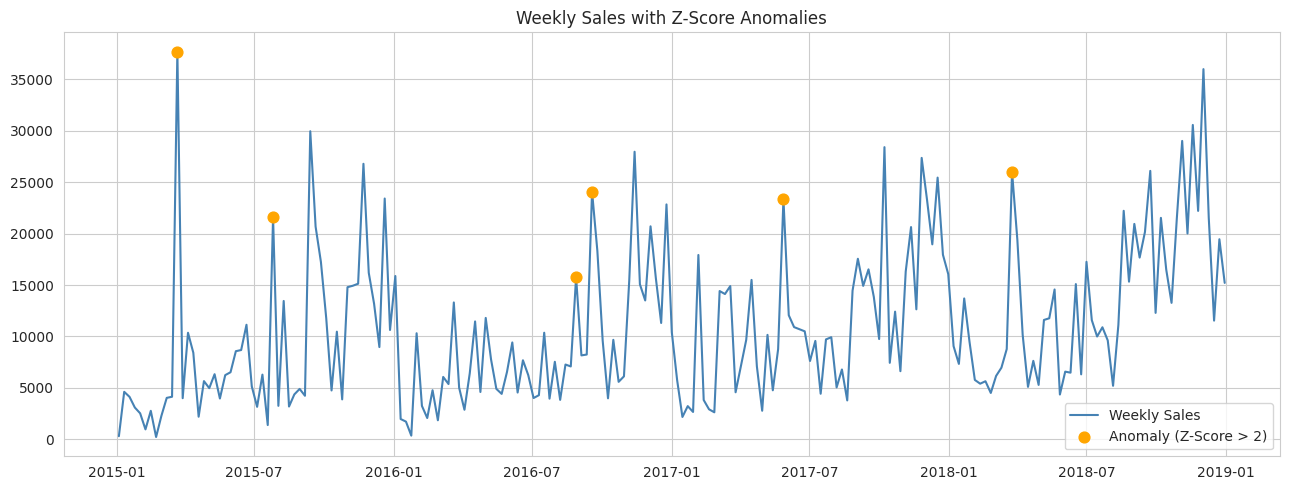

    Order Date      Sales    zscore
11  2015-03-22  37703.665  2.460650
29  2015-07-26  21590.080  2.136467
86  2016-08-28  15773.478  2.053924
89  2016-09-18  24095.960  2.122082
125 2017-05-28  23367.662  2.008225
168 2018-03-25  26029.904  2.435627


In [30]:
# Method 2: Z-score based on rolling mean/std
weekly['rolling_mean'] = weekly['Sales'].rolling(window=8, min_periods=1).mean()
weekly['rolling_std'] = weekly['Sales'].rolling(window=8, min_periods=1).std()
weekly['zscore'] = (weekly['Sales'] - weekly['rolling_mean']) / weekly['rolling_std']
weekly['anomaly_zscore'] = weekly['zscore'].abs() > 2

plt.figure(figsize=(13,5))
plt.plot(weekly['Order Date'], weekly['Sales'], label='Weekly Sales', color='steelblue')
z_anomalies = weekly[weekly['anomaly_zscore']]
plt.scatter(z_anomalies['Order Date'], z_anomalies['Sales'], color='orange', s=60, zorder=5, label='Anomaly (Z-Score > 2)')
plt.title('Weekly Sales with Z-Score Anomalies')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomalies_zscore.png', dpi=150)
plt.show()

print(z_anomalies[['Order Date','Sales','zscore']])


In [31]:
# Compare the two methods
iso_dates = set(weekly[weekly['anomaly_iso']==-1]['Order Date'])
z_dates = set(weekly[weekly['anomaly_zscore']]['Order Date'])

agreed = iso_dates & z_dates
only_iso = iso_dates - z_dates
only_z = z_dates - iso_dates

print(f"Flagged by BOTH methods: {len(agreed)}")
print(f"Flagged ONLY by Isolation Forest: {len(only_iso)}")
print(f"Flagged ONLY by Z-Score: {len(only_z)}")
explanation = (
    "Isolation Forest looks at the global distribution of all weekly sales values, "
    "while Z-Score reacts to local, recent deviations via the rolling window. "
    "Where they disagree, it's usually because Z-Score is more sensitive to a sudden "
    "short-term jump even if that value isn't extreme compared to the whole year, "
    "while Isolation Forest is more sensitive to values that are extreme overall "
    "even if the recent weeks nearby were already trending that way."
)
print("\n>>>", explanation)


Flagged by BOTH methods: 1
Flagged ONLY by Isolation Forest: 10
Flagged ONLY by Z-Score: 5

>>> Isolation Forest looks at the global distribution of all weekly sales values, while Z-Score reacts to local, recent deviations via the rolling window. Where they disagree, it's usually because Z-Score is more sensitive to a sudden short-term jump even if that value isn't extreme compared to the whole year, while Isolation Forest is more sensitive to values that are extreme overall even if the recent weeks nearby were already trending that way.


In [32]:
vg = pd.read_csv('vgsales.csv')
print(vg.shape)
vg.head()


(16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [33]:
# Aggregate video game sales to a yearly total (Global_Sales, in millions of units)
vg_yearly = vg.groupby('Year')['Global_Sales'].sum().reset_index()
vg_yearly.columns = ['Year', 'VG_Global_Sales']
vg_yearly['Year'] = vg_yearly['Year'].astype('Int64')

print(vg_yearly.tail(10))


    Year  VG_Global_Sales
29  2009           667.30
30  2010           600.45
31  2011           515.99
32  2012           363.54
33  2013           368.11
34  2014           337.05
35  2015           264.44
36  2016            70.93
37  2017             0.05
38  2020             0.29


In [34]:
# Merge on Year with our Superstore yearly sales
superstore_yearly = df.groupby('Year')['Sales'].sum().reset_index()
superstore_yearly.columns = ['Year', 'Superstore_Sales']

merged = pd.merge(superstore_yearly, vg_yearly, on='Year', how='left')
print(merged)


   Year  Superstore_Sales  VG_Global_Sales
0  2015       479856.2081           264.44
1  2016       459436.0054            70.93
2  2017       600192.5500             0.05
3  2018       722052.0192              NaN


In [35]:
# Because industry-wide gaming sales are a reasonable proxy for 'Technology' market demand,
# we check the one year where both datasets have real data as a sanity-check comparison,
# rather than pretending we have a full 4-year overlap.
overlap = merged.dropna(subset=['VG_Global_Sales'])
print("Years with usable data in BOTH sources:")
print(overlap)

tech_yearly = df[df['Category']=='Technology'].groupby('Year')['Sales'].sum().reset_index()
tech_yearly.columns = ['Year', 'Tech_Sales']
tech_check = pd.merge(overlap, tech_yearly, on='Year', how='left')
print("\nOur Technology category sales in that same overlapping year:")
print(tech_check[['Year','Tech_Sales','VG_Global_Sales']])


Years with usable data in BOTH sources:
   Year  Superstore_Sales  VG_Global_Sales
0  2015       479856.2081           264.44
1  2016       459436.0054            70.93
2  2017       600192.5500             0.05

Our Technology category sales in that same overlapping year:
   Year  Tech_Sales  VG_Global_Sales
0  2015  173865.507           264.44
1  2016  162257.731            70.93
2  2017  221961.944             0.05


In [36]:
sub_features = df.groupby('Sub-Category').apply(lambda g: pd.Series({
    'total_sales': g['Sales'].sum(),
    'avg_order_value': g['Sales'].mean(),
})).reset_index()

# Year-over-year growth rate per sub-category
yearly_sub = df.groupby(['Sub-Category','Year'])['Sales'].sum().unstack()
growth_rate = ((yearly_sub[2018] - yearly_sub[2015]) / yearly_sub[2015] * 100)
sub_features['growth_rate'] = sub_features['Sub-Category'].map(growth_rate)

# Volatility = std dev of monthly sales per sub-category
monthly_sub = df.set_index('Order Date').groupby('Sub-Category').resample('MS')['Sales'].sum()
volatility = monthly_sub.groupby('Sub-Category').std()
sub_features['volatility'] = sub_features['Sub-Category'].map(volatility)

sub_features = sub_features.dropna()
print(sub_features)


   Sub-Category  total_sales  avg_order_value  growth_rate   volatility
0   Accessories  164186.7000       217.178175   145.055961  2579.994809
1    Appliances  104618.4030       227.926804   165.242912  1821.621539
2           Art   26705.4100        34.019631    49.649531   330.488343
3       Binders  200028.7850       134.067550    65.778638  3848.223648
4     Bookcases  113813.1987       503.598224    49.846598  2229.359867
5        Chairs  322822.7310       531.833165    20.954677  4407.232960
6       Copiers  146248.0940      2215.880212   479.729510  5104.267436
7     Envelopes   16128.0460        65.032444   -12.121345   234.265716
8     Fasteners    3001.9600        14.027850    30.468364    49.094264
9   Furnishings   89212.0180        95.823865   106.824969  1360.017867
10       Labels   12347.7260        34.587468    36.073373   223.471218
11     Machines  189238.6310      1645.553313   -29.793120  5442.477300
12        Paper   76828.3040        57.420257    91.901971  1024

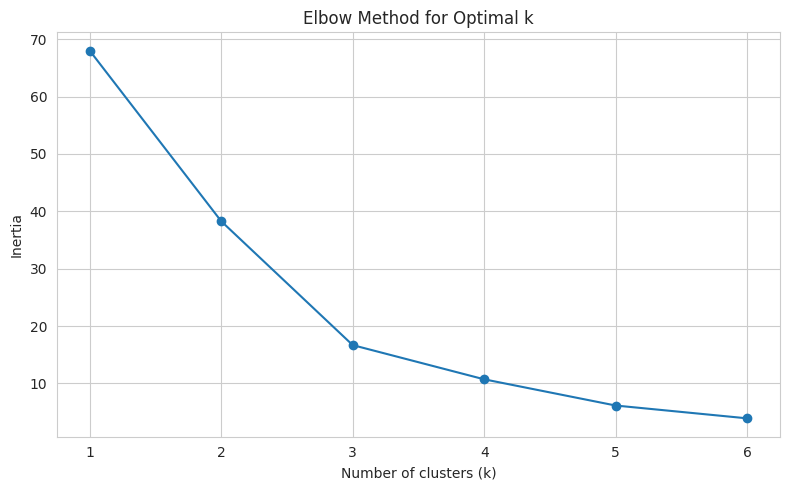

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_cols = ['total_sales','growth_rate','volatility','avg_order_value']
X_cluster = StandardScaler().fit_transform(sub_features[feature_cols])

# Elbow method
inertias = []
K_range = range(1, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150)
plt.show()


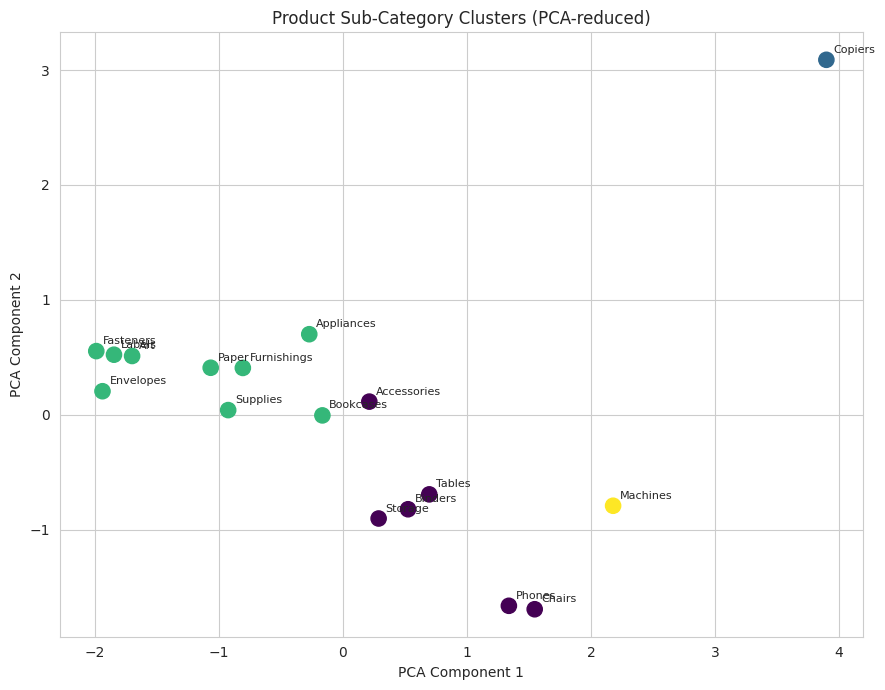

   Sub-Category  total_sales  growth_rate   volatility  cluster
0   Accessories  164186.7000   145.055961  2579.994809        0
3       Binders  200028.7850    65.778638  3848.223648        0
5        Chairs  322822.7310    20.954677  4407.232960        0
14      Storage  219343.3920    38.366108  2822.084310        0
13       Phones  327782.4480    35.557607  4052.718221        0
16       Tables  202810.6280    33.078016  3224.082504        0
6       Copiers  146248.0940   479.729510  5104.267436        1
2           Art   26705.4100    49.649531   330.488343        2
7     Envelopes   16128.0460   -12.121345   234.265716        2
4     Bookcases  113813.1987    49.846598  2229.359867        2
8     Fasteners    3001.9600    30.468364    49.094264        2
9   Furnishings   89212.0180   106.824969  1360.017867        2
12        Paper   76828.3040    91.901971  1024.824982        2
10       Labels   12347.7260    36.073373   223.471218        2
15     Supplies   46420.3080    11.27603

In [38]:
# Pick k based on where the elbow bends - typically 3-4 for this dataset size. Adjust after viewing your chart.
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
sub_features['cluster'] = kmeans.fit_predict(X_cluster)

# PCA for 2D visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_cluster)
sub_features['pca_1'] = pca_coords[:,0]
sub_features['pca_2'] = pca_coords[:,1]

plt.figure(figsize=(9,7))
scatter = plt.scatter(sub_features['pca_1'], sub_features['pca_2'], c=sub_features['cluster'], cmap='viridis', s=120)
for _, row in sub_features.iterrows():
    plt.annotate(row['Sub-Category'], (row['pca_1'], row['pca_2']), fontsize=8, xytext=(5,5), textcoords='offset points')
plt.title('Product Sub-Category Clusters (PCA-reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.savefig('charts/clusters_pca.png', dpi=150)
plt.show()

print(sub_features[['Sub-Category','total_sales','growth_rate','volatility','cluster']].sort_values('cluster'))


In [39]:
# Label clusters meaningfully based on their average characteristics
cluster_summary = sub_features.groupby('cluster')[['total_sales','growth_rate','volatility']].mean()
print(cluster_summary)

print("""
>>> Use this table to assign labels, for example:
- Highest total_sales + lowest volatility  -> "High Volume, Stable Demand"
- Lowest total_sales + highest volatility  -> "Low Volume, High Volatility"
- Highest growth_rate                       -> "Growing Demand"
- Negative or lowest growth_rate            -> "Declining Demand"

Recommended stocking strategy per cluster:
- High Volume, Stable Demand   -> keep steady safety stock, reorder on a fixed schedule
- Growing Demand               -> increase reorder quantities ahead of trend, monitor weekly
- Declining Demand             -> reduce stock commitment, consider clearance/promotion
- Low Volume, High Volatility  -> smaller, more frequent orders; avoid large stockpiles
""")


           total_sales  growth_rate   volatility
cluster                                         
0        239495.780667    56.465168  3489.056075
1        146248.094000   479.729510  5104.267436
2         54341.708189    58.795823  1027.596300
3        189238.631000   -29.793120  5442.477300

>>> Use this table to assign labels, for example:
- Highest total_sales + lowest volatility  -> "High Volume, Stable Demand"
- Lowest total_sales + highest volatility  -> "Low Volume, High Volatility"
- Highest growth_rate                       -> "Growing Demand"
- Negative or lowest growth_rate            -> "Declining Demand"

Recommended stocking strategy per cluster:
- High Volume, Stable Demand   -> keep steady safety stock, reorder on a fixed schedule
- Growing Demand               -> increase reorder quantities ahead of trend, monitor weekly
- Declining Demand             -> reduce stock commitment, consider clearance/promotion
- Low Volume, High Volatility  -> smaller, more frequent orde